# 贷款审批预测 - EDA 探索

本笔记本用于机器学习大作业的数据探索分析（Exploratory Data Analysis）。

探索目标：
- 了解数据规模、字段类型与缺失值
- 分析标签分布与类别不平衡
- 分析核心数值特征分布与偏态
- 分析关键类别变量与标签关系
- 产出可用于报告的图表到 `outputs/figures/eda/`


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', 200)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
EDA_FIG_DIR = PROJECT_ROOT / 'outputs' / 'figures' / 'eda'
EDA_FIG_DIR.mkdir(parents=True, exist_ok=True)

train_path = RAW_DIR / 'train.csv'
test_path = RAW_DIR / 'test.csv'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('train.csv exists =', train_path.exists())
print('test.csv exists =', test_path.exists())


PROJECT_ROOT = /Users/aaaa/Documents/GitHub/loan-approval-ml
train.csv exists = True
test.csv exists = True


In [3]:
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print('train shape:', train.shape)
print('test shape :', test.shape)

train.head()


train shape: (614, 13)
test shape : (367, 12)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
missing = train.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_ratio = (missing / len(train)).round(4)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_ratio': missing_ratio
})
missing_df


,missing_count,missing_ratio
Credit_History,50,0.0814
Self_Employed,32,0.0521
LoanAmount,22,0.0358
Dependents,15,0.0244
Loan_Amount_Term,14,0.0228
Gender,13,0.0212
Married,3,0.0049


Target counts:
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Target ratio:
Loan_Status
Y    0.6873
N    0.3127
Name: proportion, dtype: float64


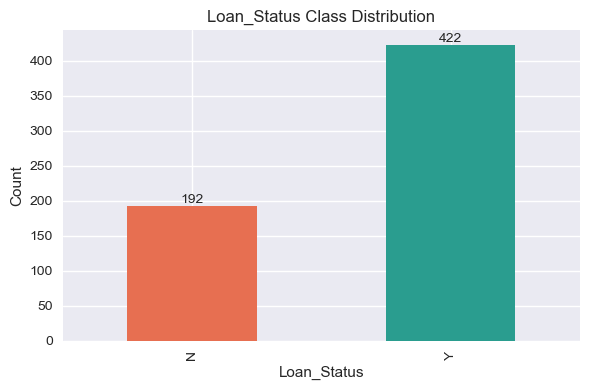

In [6]:
target_map = {'Y': 1, 'N': 0}
y = train['Loan_Status']
target_counts = y.value_counts()
target_ratio = y.value_counts(normalize=True).round(4)

print('Target counts:')
print(target_counts)
print('\nTarget ratio:')
print(target_ratio)

fig, ax = plt.subplots(figsize=(6, 4))
target_counts.sort_index().plot(kind='bar', ax=ax, color=['#E76F51', '#2A9D8F'])
ax.set_title('Loan_Status Class Distribution')
ax.set_xlabel('Loan_Status')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
fig.tight_layout()
fig.savefig(EDA_FIG_DIR / 'target_distribution.png', dpi=150)
plt.show()


In [7]:
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
train[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


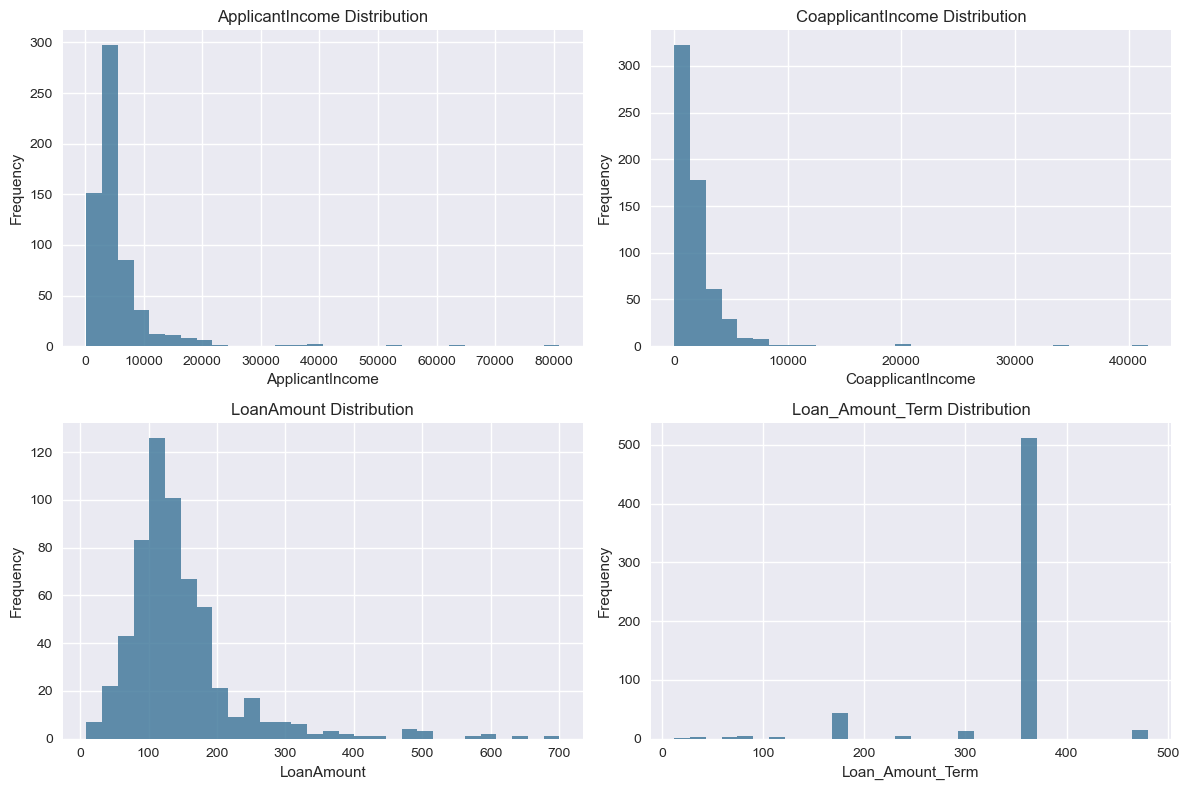

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
for ax, col in zip(axes.flatten(), plot_cols):
    ax.hist(train[col].dropna(), bins=30, color='#457B9D', alpha=0.85)
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
fig.tight_layout()
fig.savefig(EDA_FIG_DIR / 'numeric_histograms.png', dpi=150)
plt.show()


In [9]:
# 简单偏度检查：判断是否需要对数变换
skewness = train[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']].skew(numeric_only=True).sort_values(ascending=False)
skewness


CoapplicantIncome    7.491531
ApplicantIncome      6.539513
LoanAmount           2.677552
dtype: float64

In [10]:
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Dependents', 'Credit_History']

for col in cat_cols:
    ctab = pd.crosstab(train[col], train['Loan_Status'], normalize='index').round(3)
    print(f'=== {col} vs Loan_Status (row-normalized) ===')
    display(ctab)


=== Gender vs Loan_Status (row-normalized) ===


Loan_Status,N,Y
Gender,,
Female,0.330,0.670
Male,0.307,0.693


=== Married vs Loan_Status (row-normalized) ===


Loan_Status,N,Y
Married,,
No,0.371,0.629
Yes,0.284,0.716


=== Education vs Loan_Status (row-normalized) ===


...

Loan_Status,N,Y
Property_Area,,
Rural,0.385,0.615
Semiurban,0.232,0.768
Urban,0.342,0.658


=== Dependents vs Loan_Status (row-normalized) ===


Loan_Status,N,Y
Dependents,,
0,0.310,0.690
1,0.353,0.647
2,0.248,0.752
3+,0.353,0.647


=== Credit_History vs Loan_Status (row-normalized) ===


Loan_Status,N,Y
Credit_History,,
0.0,0.921,0.079
1.0,0.204,0.796


In [11]:
# 构造与项目代码一致的三个业务特征（EDA 阶段先看分布）
eda_df = train.copy()
eda_df['TotalIncome'] = eda_df['ApplicantIncome'] + eda_df['CoapplicantIncome']
eda_df['EMI'] = eda_df['LoanAmount'] / eda_df['Loan_Amount_Term']
eda_df['BalanceIncome'] = eda_df['TotalIncome'] - eda_df['EMI'] * 1000

eda_df[['TotalIncome', 'EMI', 'BalanceIncome']].describe().T


,count,mean,std,min,25%,50%,75%,max
TotalIncome,614.0,7024.705081,6458.663872,1442.000,4166.000000,5416.500000,7521.750000,81000.00
EMI,578.0,0.480300,0.525459,0.025,0.286111,0.365278,0.513889,9.25
BalanceIncome,578.0,6595.321119,6423.234081,-1768.000,3796.638889,4970.333333,6958.027778,80000.00


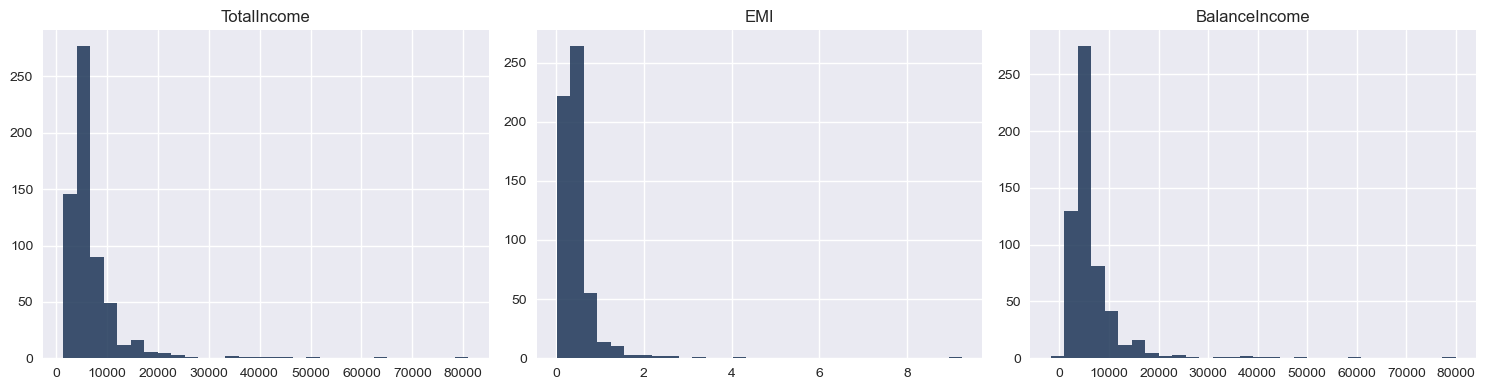

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['TotalIncome', 'EMI', 'BalanceIncome']):
    ax.hist(eda_df[col].dropna(), bins=30, color='#1D3557', alpha=0.85)
    ax.set_title(col)
fig.tight_layout()
fig.savefig(EDA_FIG_DIR / 'derived_feature_histograms.png', dpi=150)
plt.show()


## 可直接写入报告的结论模板

1. 训练集存在多个字段缺失值（如 `Credit_History`、`Self_Employed`、`LoanAmount`），需在预处理阶段系统填充。
2. 标签 `Loan_Status` 存在类别不平衡，建模时应关注 ROC-AUC/F1，并考虑类别权重。
3. `ApplicantIncome`、`CoapplicantIncome`、`LoanAmount` 呈明显右偏分布，适合做 `log1p` 变换。
4. `Credit_History` 与贷款获批关系较强，是关键预测因子之一。
5. 业务派生特征（`TotalIncome`、`EMI`、`BalanceIncome`）可补充偿债能力信息。
